# Cross-Algorithm Comparison & Analysis

Run this **after** all four training notebooks have completed at least once (it reads their saved
results/models from Google Drive). This notebook produces the cross-algorithm plots and tables required
for the "Discussion & Analysis" section of the report: combined cumulative-reward curves, a convergence
comparison, a generalization/robustness comparison, and the final metrics table.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = "/content/drive/MyDrive/student_name_rl_summative"
RESULTS_DIR = f"{PROJECT_DIR}/results"
sys.path.insert(0, PROJECT_DIR)

ALGOS = ["dqn", "reinforce", "ppo", "a2c"]
ALGO_LABELS = {"dqn": "DQN", "reinforce": "REINFORCE", "ppo": "PPO", "a2c": "A2C"}

Mounted at /content/drive


In [2]:
from environment.custom_env import MedicalDroneEnv
env = MedicalDroneEnv()
print("Environment loaded OK:", env.observation_space.shape)

Environment loaded OK: (38,)


## 1. Load each algorithm's best-run metrics and hyperparameter tables

In [3]:
summary_rows = []
hp_tables = {}
for algo in ALGOS:
    try:
        with open(f"{RESULTS_DIR}/{algo}/best_model_metrics.json") as f:
            m = json.load(f)
        m["algorithm"] = ALGO_LABELS[algo]
        summary_rows.append(m)
        hp_tables[algo] = pd.read_csv(f"{RESULTS_DIR}/{algo}/hyperparameter_results.csv")
    except FileNotFoundError:
        print(f"[!] No results found yet for {algo} — run its training notebook first.")

summary_df = pd.DataFrame(summary_rows)
cols = ["algorithm", "success_rate", "avg_reward", "reward_std", "avg_steps",
        "avg_battery_left", "avg_hazard_violations", "avg_path_efficiency"]
summary_df = summary_df[[c for c in cols if c in summary_df.columns]]
summary_df.to_csv(f"{RESULTS_DIR}/final_comparison_table.csv", index=False)
summary_df

,algorithm,success_rate,avg_reward,reward_std,avg_steps,avg_battery_left,avg_hazard_violations,avg_path_efficiency
0,DQN,0.0,-110.266667,35.152699,32.200000,38.450000,5.033333,1.020495
1,REINFORCE,0.0,-119.500000,32.449448,23.000000,0.000000,3.700000,1.529096
2,PPO,0.0,-112.616667,48.865408,22.966667,0.000000,5.866667,1.142798
3,A2C,0.0,-117.783333,44.125330,22.500000,15.969639,3.333333,1.195061


## 2. Cumulative reward curves — all four methods (required plot)

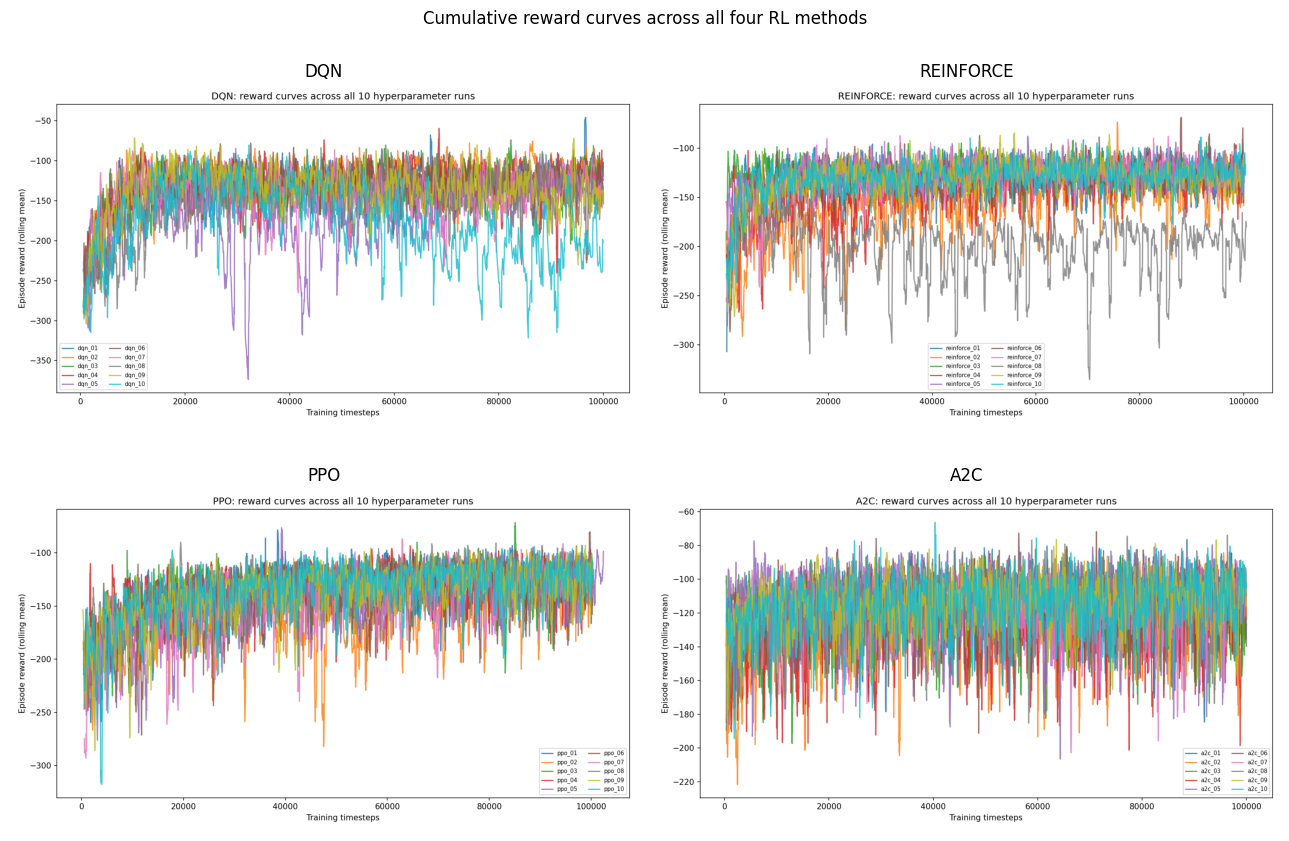

In [4]:
import glob

def load_best_curve(algo):
    """Reconstruct the best run's smoothed reward curve from its saved Monitor csv if present,
    otherwise fall back to the hyperparameter_results table for a single-point comparison."""
    monitor_files = glob.glob(f"{RESULTS_DIR}/{algo}/*monitor*.csv")
    return monitor_files

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=False)
for ax, algo in zip(axes.flat, ALGOS):
    png_candidates = glob.glob(f"{RESULTS_DIR}/{algo}/all_runs_reward_curves.png")
    ax.set_title(ALGO_LABELS[algo])
    ax.set_xlabel("Training timesteps")
    ax.set_ylabel("Episode reward (rolling mean)")
    if png_candidates:
        img = plt.imread(png_candidates[0])
        ax.imshow(img)
        ax.axis("off")
    else:
        ax.text(0.5, 0.5, "Run training notebook first", ha="center", va="center")
plt.suptitle("Cumulative reward curves across all four RL methods")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/combined_reward_curves.png", dpi=150)
plt.show()

## 3. Convergence comparison — best run per algorithm, overlaid
If you also save each algorithm's raw `(timesteps, smoothed_reward)` arrays as CSV from the training notebooks (optional, add a `to_csv` there), load and overlay them here for a single combined line chart instead of the image-grid above. Placeholder cell below shows the pattern.

In [5]:
# Example pattern once you export per-run curve CSVs from each training notebook:
# curve_csv = f"{RESULTS_DIR}/{algo}/best_run_curve.csv"
# df = pd.read_csv(curve_csv)
# plt.plot(df["timesteps"], df["smoothed_reward"], label=ALGO_LABELS[algo])
#
# plt.xlabel("Training timesteps"); plt.ylabel("Reward"); plt.legend(); plt.title("Convergence comparison")
print("See markdown above — populate once curve CSVs are exported from each training notebook.")

See markdown above — populate once curve CSVs are exported from each training notebook.


## 4. Generalization / robustness comparison across hard scenarios

In [6]:
scenario_rows = []
for algo in ALGOS:
    try:
        with open(f"{RESULTS_DIR}/{algo}/scenario_results.json") as f:
            s = json.load(f)
        s["algorithm"] = ALGO_LABELS[algo]
        scenario_rows.append(s)
    except FileNotFoundError:
        pass

scenario_df = pd.DataFrame(scenario_rows).set_index("algorithm")
scenario_df

,low_battery,dense_hazards,standard
algorithm,,,
DQN,0.0,0.0,0.0
REINFORCE,0.0,0.0,0.0
PPO,0.0,0.0,0.0
A2C,0.0,0.0,0.0


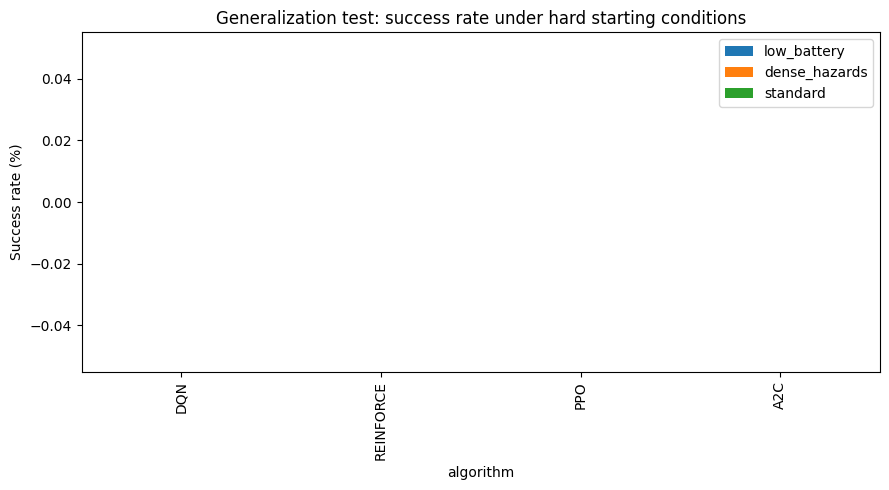

In [7]:
if not scenario_df.empty:
    ax = scenario_df.plot(kind="bar", figsize=(9, 5))
    ax.set_ylabel("Success rate (%)")
    ax.set_title("Generalization test: success rate under hard starting conditions")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/generalization_comparison.png", dpi=150)
    plt.show()
else:
    print("No scenario results found yet.")

## 5. Stability comparison (reward standard deviation)

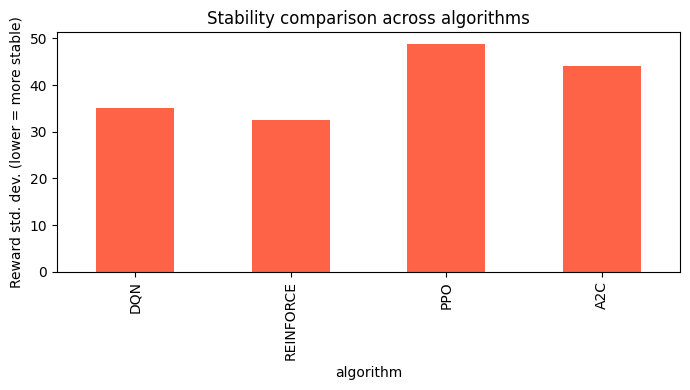

In [8]:
if not summary_df.empty:
    ax = summary_df.set_index("algorithm")["reward_std"].plot(kind="bar", figsize=(7, 4), color="tomato")
    ax.set_ylabel("Reward std. dev. (lower = more stable)")
    ax.set_title("Stability comparison across algorithms")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/stability_comparison.png", dpi=150)
    plt.show()

## 6. Discussion prompts for the report

Use the plots/tables above to answer, in the final PDF report:
- **Which algorithm reached the highest success rate**, and does that line up with the hyperparameters
  that theory would predict (e.g. PPO's clipping making it robust to a higher learning rate)?
- **Which algorithm was most stable** (lowest reward std. dev.) across evaluation episodes, and is that
  consistent with which algorithm bootstraps value estimates (DQN, PPO, A2C) vs. pure Monte-Carlo
  (REINFORCE)?
- **How did each algorithm's generalization scores** (low battery / dense hazards vs. standard) compare —
  did any algorithm overfit to "typical" episodes and fail disproportionately on the harder scenarios?
- **Battery efficiency and hazard violations** — which algorithm learned the safest, most efficient
  policy, and which took the most risks (e.g. flying through storms to save time)?
